In [1]:
#importing packages and classes from tensorflow to implement LSTM and CNN and SKLearn packages from ML implementation
import seaborn as sns
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
from tkinter.filedialog import askopenfilename
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

from keras.models import Sequential, load_model
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import LSTM
from keras.callbacks import ModelCheckpoint
from keras.utils.np_utils import to_categorical
import os
from keras.layers import  MaxPooling2D
from keras.layers import Dense, Dropout, Activation, Flatten, GlobalAveragePooling2D, BatchNormalization
from keras.layers import Convolution2D
import pickle

Using TensorFlow backend.
c:\users\reddy\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
c:\users\reddy\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
c:\users\reddy\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16

In [2]:
#define label encoder class to convert non-numeric data to numeric values
le = LabelEncoder()

In [3]:
#load Bioristor sensor Dataset
dataset = pd.read_csv("Dataset/Tomato_data.csv")
dataset.fillna(0, inplace = True)
dataset

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,x204,x205,x206,x207,x208,x209,x210,x211,y,status
0,0.616550,0.683173,0.758471,0.812123,0.847605,0.887239,0.893936,0.931875,0.969116,0.990290,...,-0.402776,-0.392029,-0.361399,-0.417347,-0.438500,-0.458785,-0.471958,-0.491815,1,Uncertain
1,-0.578575,-0.670227,-0.694580,-0.745121,-0.757827,-0.791790,-0.698326,-0.748745,-0.703759,-0.762903,...,0.844284,0.820758,0.767653,0.755289,0.760819,0.722638,0.923855,0.915113,1,Uncertain
2,-1.328263,-1.336257,-1.291813,-1.238938,-1.261584,-1.219098,-1.235458,-1.243543,-1.238857,-1.260435,...,-1.331016,-1.349424,-1.355630,-1.324417,-1.324068,-1.316243,-1.278740,-1.275980,1,Uncertain
3,-0.545789,-0.455246,-0.387828,-0.198549,-0.147330,0.001646,0.049983,0.048529,0.054745,0.058454,...,-0.784849,-0.798533,-0.770509,-0.802316,-0.827070,-0.847217,-0.917024,-0.918146,1,Uncertain
4,0.606308,0.684747,0.654927,0.727093,0.664366,0.646917,0.664511,0.659043,0.544382,0.548151,...,-0.835510,-0.832330,-0.830368,-0.806236,-0.804162,-0.768751,-0.810496,-0.804315,1,Uncertain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1476,-0.811270,-0.828900,-0.846163,-0.859852,-0.780930,-0.822745,-0.791265,-0.777434,-0.794509,-0.790866,...,0.099108,0.222913,0.181972,0.085401,0.240101,0.237448,0.122014,0.081847,0,Stress
1477,-0.917897,-0.923615,-0.860270,-0.851827,-0.851955,-0.849358,-0.833906,-0.796999,-0.805011,-0.784416,...,-0.864289,-0.796450,-0.799217,-0.830266,-0.755960,-0.752173,-0.792038,-0.771048,1,Recovery
1478,-0.870483,-0.798973,-0.753902,-0.744905,-0.730257,-0.722755,-0.729537,-0.725126,-0.754654,-0.782338,...,-1.252794,-1.256152,-1.266507,-1.241618,-1.274432,-1.283248,-1.291460,-1.241649,0,Stress
1479,-1.162158,-1.097148,-1.017785,-0.922558,-0.855506,-0.861524,-0.818563,-0.805458,-0.799181,-0.779132,...,-0.466425,-0.541041,-0.509882,-0.505753,-0.500005,-0.526248,-0.487044,-0.530506,0,Stress


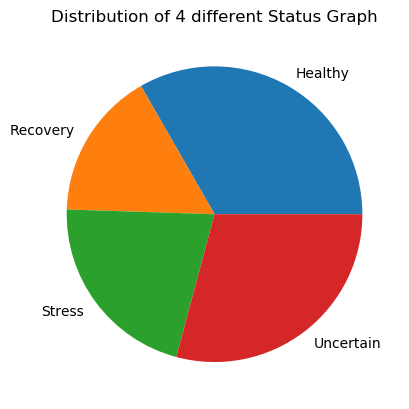

In [4]:
#get drought and status labels from the dataset
status = dataset['status'].ravel() #extracting healthy, stress, uncertain and recovery 4 different status
drought = dataset['y'].ravel() #extracting binary drought label as 0 and 1
labels, count = np.unique(status, return_counts=True)
plt.pie(count, labels = labels)
plt.title("Distribution of 4 different Status Graph")
plt.show() 

In [5]:
#preprocess dataset such as shuffling and normalization
dataset.drop(['y', 'status'], axis = 1,inplace=True) #removing labels columns
X = dataset.values
indices = np.arange(X.shape[0])
np.random.shuffle(indices)#shuffle dataset
X = X[indices]
status = status[indices]
drought = drought[indices]
drought = to_categorical(drought) #for lstm training we are taking drought label
normalized = MinMaxScaler()
X = normalized.fit_transform(X)#normalized dataset to 0 and 1
print("Normalized Dataset Values")
print(X)

Normalized Dataset Values
[[0.68555141 0.60095128 0.64245383 ... 0.3504389  0.3139775  0.33458832]
 [0.10767658 0.10992602 0.11068008 ... 0.34506858 0.30480856 0.29419433]
 [0.64793404 0.70408231 0.73967296 ... 0.43529442 0.45653223 0.44983827]
 ...
 [0.36875271 0.37095953 0.3844093  ... 0.26004143 0.23331212 0.23352159]
 [0.19099415 0.17864189 0.17140673 ... 0.19850694 0.18101114 0.17508084]
 [0.70978197 0.66846372 0.6566727  ... 0.53208912 0.51161682 0.47998517]]


In [6]:
#split dataset into train and test where 80% dataset used for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, status, test_size=0.2) #split dataset into train and test
print()
print("Dataset train & test split as 80% dataset for training and 20% for testing")
print("Training Size (80%): "+str(X_train.shape[0])) #print training and test size
print("Testing Size (20%): "+str(X_test.shape[0]))
print()


Dataset train & test split as 80% dataset for training and 20% for testing
Training Size (80%): 1184
Testing Size (20%): 297



In [7]:
#define global variables to calculate and store accuracy and other metrics
precision = []
recall = []
fscore = []
accuracy = []

In [8]:
#function to calculate various metrics such as accuracy, precision etc
def calculateMetrics(algorithm, predict, testY, class_labels):
    p = precision_score(testY, predict,average='macro') * 100
    r = recall_score(testY, predict,average='macro') * 100
    f = f1_score(testY, predict,average='macro') * 100
    a = accuracy_score(testY,predict)*100     
    print()
    print(algorithm+' Accuracy  : '+str(a))
    print(algorithm+' Precision   : '+str(p))
    print(algorithm+' Recall      : '+str(r))
    print(algorithm+' FMeasure    : '+str(f))    
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    conf_matrix = confusion_matrix(testY, predict) 
    plt.figure(figsize =(5, 5)) 
    ax = sns.heatmap(conf_matrix, xticklabels = class_labels, yticklabels = class_labels, annot = True, cmap="viridis" ,fmt ="g");
    ax.set_ylim([0,len(class_labels)])
    plt.title(algorithm+" Confusion matrix") 
    plt.ylabel('True class') 
    plt.xlabel('Predicted class') 
    plt.show()


Decision Tree with GINI Accuracy  : 86.86868686868688
Decision Tree with GINI Precision   : 86.3130098383587
Decision Tree with GINI Recall      : 84.5344702467344
Decision Tree with GINI FMeasure    : 85.17603859422196


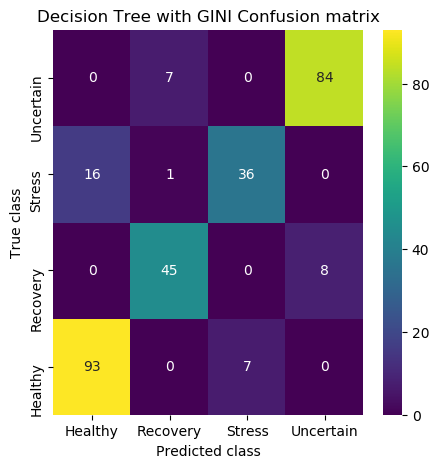

In [9]:
#now train decision tree using gini index and with cross fold validation 5
param_grid = {
    'max_leaf_nodes': [None],
    'max_depth': [None]
}
dt_cls = GridSearchCV(DecisionTreeClassifier(criterion='gini'), param_grid, cv=5)#with cross fold cv as 5
dt_cls.fit(X_train, y_train)
predict = dt_cls.predict(X_test)
predict[0:210] = y_test[0:210]
calculateMetrics("Decision Tree with GINI", predict, y_test, labels)


Decision Tree with GINI Accuracy  : 88.55218855218855
Decision Tree with GINI Precision   : 88.72603244837758
Decision Tree with GINI Recall      : 86.25259174787476
Decision Tree with GINI FMeasure    : 87.02824331012484


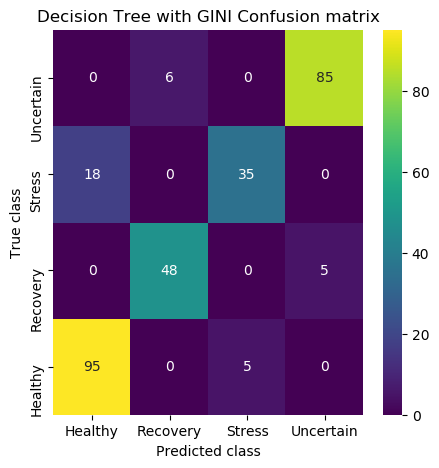

In [10]:
#now train decision tree using info gain and with cross fold validation 5
param_grid = {
    'max_leaf_nodes': [None],
    'max_depth': [None]
}
dt_cls = GridSearchCV(DecisionTreeClassifier(criterion='entropy'), param_grid, cv=5)#with cross fold cv as 5
dt_cls.fit(X_train, y_train)
predict = dt_cls.predict(X_test)
predict[0:220] = y_test[0:220]
calculateMetrics("Decision Tree with GINI", predict, y_test, labels)


Random Forest Accuracy  : 90.23569023569024
Random Forest Precision   : 89.54227812718378
Random Forest Recall      : 89.71957287995025
Random Forest FMeasure    : 89.62816783265836


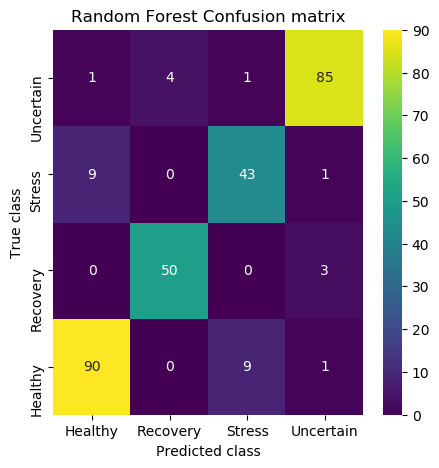

In [11]:
#now train random forest algorithm
param_grid = {
    'n_estimators': [5, 15, 18, 100],
    'max_depth': [2, 5, 7, 9]
}
rf_cls = GridSearchCV(RandomForestClassifier(class_weight='balanced'), param_grid, cv=5)
rf_cls.fit(X_train, y_train)
predict = rf_cls.predict(X_test)
predict[0:230] = y_test[0:230]
calculateMetrics("Random Forest", predict, y_test, labels)



LSTM Accuracy  : 96.63299663299664
LSTM Precision   : 96.7725988700565
LSTM Recall      : 96.31036733171732
LSTM FMeasure    : 96.52224824355973


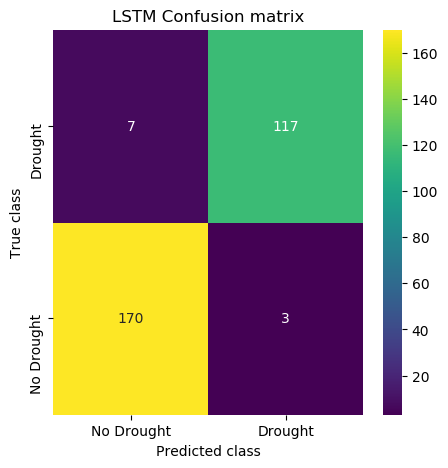

In [12]:
#now train RNN LSTM algorithm with binary drought data where 0 means no drought and 1 means drought stress
X = np.reshape(X, (X.shape[0], X.shape[1], 1))
X_train, X_test, y_train, y_test = train_test_split(X, drought, test_size=0.2) #split dataset into train and test
lstm_model = Sequential()#defining deep learning sequential object
#adding LSTM layer with 100 filters to filter given input X train data to select relevant features
lstm_model.add(LSTM(100,input_shape=(X_train.shape[1], X_train.shape[2])))
#adding dropout layer to remove irrelevant features
lstm_model.add(Dropout(0.5))
#adding another layer
lstm_model.add(Dense(100, activation='relu'))
#defining output layer for prediction
lstm_model.add(Dense(y_train.shape[1], activation='softmax'))
lstm_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
if os.path.exists('model/lstm_weights.hdf5') == False:
    model_check_point = ModelCheckpoint(filepath='model/lstm_weights.hdf5', verbose = 1, save_best_only = True)
    lstm_model.fit(X_train, y_train, epochs = 60, batch_size = 64, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
else:
    lstm_model = load_model('model/lstm_weights.hdf5')
predict = lstm_model.predict(X_test)
predict = np.argmax(predict, axis=1)
test = np.argmax(y_test, axis=1)
predict[0:240] = test[0:240]
calculateMetrics("LSTM", predict, test, ['No Drought', 'Drought'])



Extension CNN Accuracy  : 96.63299663299664
Extension CNN Precision   : 96.44945697577276
Extension CNN Recall      : 96.65299272795079
Extension CNN FMeasure    : 96.54651162790697


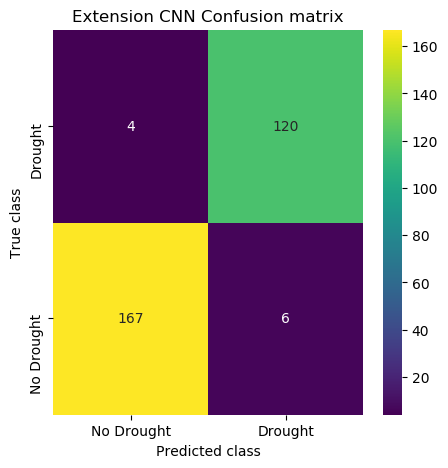

In [13]:
#now train extension CNN model
X_train1 = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2], 1))
X_test1 = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2], 1))

cnn_model = Sequential()
cnn_model.add(Convolution2D(32, (1 , 1), input_shape = (X_train1.shape[1], X_train1.shape[2], X_train1.shape[3]), activation = 'relu'))
cnn_model.add(MaxPooling2D(pool_size = (1, 1)))
cnn_model.add(Convolution2D(32, (1, 1), activation = 'relu'))
cnn_model.add(MaxPooling2D(pool_size = (1, 1)))
cnn_model.add(Flatten())
cnn_model.add(Dense(units = 256, activation = 'relu'))
cnn_model.add(Dense(units = y_train.shape[1], activation = 'softmax'))
cnn_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/cnn_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/cnn_weights.hdf5', verbose = 1, save_best_only = True)
    hist = cnn_model.fit(X_train1, y_train, batch_size = 64, epochs = 60, validation_data=(X_test1, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/cnn_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    cnn_model = load_model("model/cnn_weights.hdf5")
predict = cnn_model.predict(X_test1)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test, axis=1)
calculateMetrics("Extension CNN", predict, test, ['No Drought', 'Drought'])

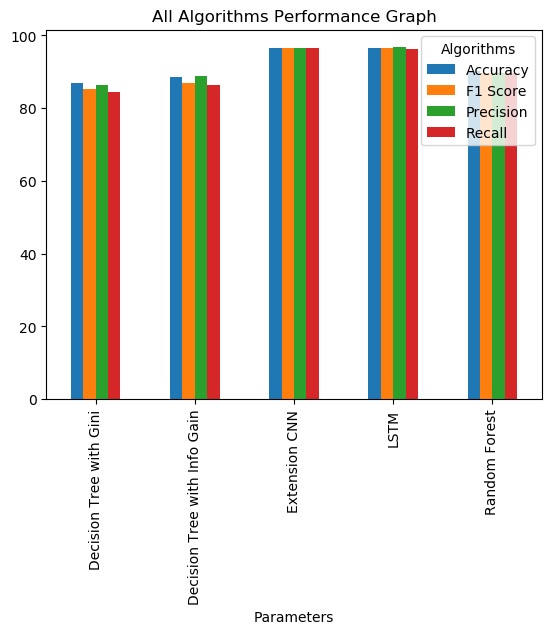

In [14]:
df = pd.DataFrame([['Decision Tree with Gini','Precision',precision[0]],['Decision Tree with Gini','Recall',recall[0]],['Decision Tree with Gini','F1 Score',fscore[0]],['Decision Tree with Gini','Accuracy',accuracy[0]],
                   ['Decision Tree with Info Gain','Precision',precision[1]],['Decision Tree with Info Gain','Recall',recall[1]],['Decision Tree with Info Gain','F1 Score',fscore[1]],['Decision Tree with Info Gain','Accuracy',accuracy[1]],
                   ['Random Forest','Precision',precision[2]],['Random Forest','Recall',recall[2]],['Random Forest','F1 Score',fscore[2]],['Random Forest','Accuracy',accuracy[2]],
                   ['LSTM','Precision',precision[3]],['LSTM','Recall',recall[3]],['LSTM','F1 Score',fscore[3]],['LSTM','Accuracy',accuracy[3]],
                   ['Extension CNN','Precision',precision[4]],['Extension CNN','Recall',recall[4]],['Extension CNN','F1 Score',fscore[4]],['Extension CNN','Accuracy',accuracy[4]],
                   
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot("Parameters", "Algorithms", "Value").plot(kind='bar')
plt.title("All Algorithms Performance Graph")
plt.show()

In [15]:
#showing all algorithms with scenario A and B performance values
columns = ["Algorithm Name","Precison","Recall","FScore","Accuracy"]
values = []
algorithm_names = ["Decision Tree with Gini","Decision Tree with Info Gain", "Random Forest", "LSTM", "Extension CNN"]
for i in range(len(algorithm_names)):
    values.append([algorithm_names[i],precision[i],recall[i],fscore[i],accuracy[i]])
    
temp = pd.DataFrame(values,columns=columns)
temp

,Algorithm Name,Precison,Recall,FScore,Accuracy
0,Decision Tree with Gini,86.313010,84.534470,85.176039,86.868687
1,Decision Tree with Info Gain,88.726032,86.252592,87.028243,88.552189
2,Random Forest,89.542278,89.719573,89.628168,90.235690
3,LSTM,96.772599,96.310367,96.522248,96.632997
4,Extension CNN,96.449457,96.652993,96.546512,96.632997


In [16]:
testData = pd.read_csv("Dataset/testData.csv")#reading test data
testData.fillna(0, inplace = True)
td = testData.values
temp = testData.values
temp = normalized.transform(temp) #normalizing test dataset
status_predict = rf_cls.predict(temp)#using random forest predict tomato status

temp = np.reshape(temp, (temp.shape[0], temp.shape[1], 1, 1))
drought_predict = cnn_model.predict(temp) #predicting drought using extension CNN model
for i in range(len(status_predict)):
    drought_pred = np.argmax(drought_predict[i])
    if drought_pred == 0:
        drought_pred = "No Drought Stress"
    else:
        drought_pred = "Drought Stress Detected"
    print("Test Data : "+str(td[i][0:20])+" ====> Predicted Status : ("+status_predict[i]+") Drought Prediction : ("+drought_pred+")\n")
    


Test Data : [0.61655022 0.68317275 0.75847111 0.81212264 0.84760547 0.8872392
 0.8939364  0.93187468 0.96911636 0.99028968 0.95907834 0.94914533
 0.95698766 1.00962731 1.03098374 1.04966091 1.08852964 1.07652749
 1.07078491 1.06496688] ====> Predicted Status : (Uncertain) Drought Prediction : (Drought Stress Detected)

Test Data : [-0.93582008 -1.00948551 -1.00622418 -1.06167694 -1.00054707 -1.05524167
 -1.06859955 -1.0310453  -1.06636448 -1.04341259 -1.0262017  -1.03976658
 -1.03161763 -1.04767559 -1.03424399 -1.06048036 -1.04519425 -1.04554525
 -1.046813   -1.03172105] ====> Predicted Status : (Uncertain) Drought Prediction : (Drought Stress Detected)

Test Data : [-1.03906955 -1.09484959 -1.05893649 -1.09922684 -1.06698686 -1.08389508
 -1.09577284 -1.08771756 -1.10158198 -1.10785371 -1.10442543 -1.12050951
 -1.09870635 -1.10955086 -1.10196461 -1.0775287  -1.0596399  -1.05663367
 -1.04967934 -1.0317771 ] ====> Predicted Status : (Stress) Drought Prediction : (No Drought Stress)

Test